# 02 — Exploratory Data Analysis del dataset finale v1

Questo notebook analizza il dataset ricostruito dopo:

1. filtering preliminare;
2. separazione tra natural language e code-like content;
3. classificazione del task e della lingua;
4. ricostruzione del dataset finale in Parquet.

L'obiettivo è controllare la qualità del nuovo dataset e descrivere le distribuzioni principali prima delle analisi successive.

## 0. Setup dell'ambiente

In questa sezione centralizzo i path, preparo le directory di output e definisco alcune funzioni riutilizzabili per tabelle e grafici.

In [22]:
from __future__ import annotations

import json
import math
from collections import Counter
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter, PercentFormatter
from tqdm.auto import tqdm
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.width", 180)

# ============================================================
# Configurazione principale
# ============================================================

DATASET_VERSION = "v1"

FINAL_DATASET_DIR = Path("../data/final/v1")
PROCESSED_JSONL_DIR = Path("../data/processed/v1")
RECONSTRUCTION_REPORT_PATH = FINAL_DATASET_DIR / "reconstruction_report.json"

OUTPUT_DIR = Path("outputs") / f"eda_final_{DATASET_VERSION}"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

for directory in [OUTPUT_DIR, FIGURES_DIR, TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TOP_N = 25
RANDOM_SEED = 42

print(f"FINAL_DATASET_DIR: {FINAL_DATASET_DIR.resolve()}")
print(f"PROCESSED_JSONL_DIR: {PROCESSED_JSONL_DIR.resolve()}")
print(f"OUTPUT_DIR: {OUTPUT_DIR.resolve()}")

FINAL_DATASET_DIR: C:\Users\franc\PycharmProjects\Prompt-Quality-Technical-Debt-Thesis\data\final\v1
PROCESSED_JSONL_DIR: C:\Users\franc\PycharmProjects\Prompt-Quality-Technical-Debt-Thesis\data\processed\v1
OUTPUT_DIR: C:\Users\franc\PycharmProjects\Prompt-Quality-Technical-Debt-Thesis\notebooks\outputs\eda_final_v1


## 1. Caricamento del dataset finale

Carico tutti i file Parquet presenti nella directory finale. Ogni file viene tracciato con una colonna `_source_file`, utile per eventuali controlli di provenienza.

In [23]:
def load_parquet_dataset(dataset_dir: Path) -> pd.DataFrame:
    parquet_files = sorted(dataset_dir.glob("*.parquet"))

    if not parquet_files:
        raise FileNotFoundError(f"No parquet files found in {dataset_dir}")

    dfs = []
    for parquet_path in tqdm(parquet_files, desc="Loading parquet files"):
        part_df = pd.read_parquet(parquet_path)
        part_df["_source_file"] = parquet_path.name
        dfs.append(part_df)

    return pd.concat(dfs, ignore_index=True)

final_df = load_parquet_dataset(FINAL_DATASET_DIR)

print(f"Numero totale di record: {len(final_df):,}")
print(f"Numero di colonne: {final_df.shape[1]:,}")
print(f"Numero di file sorgente: {final_df['_source_file'].nunique():,}")

display(final_df.head(3))

Loading parquet files: 100%|██████████| 7/7 [00:02<00:00,  2.67it/s]

Numero totale di record: 61,835
Numero di colonne: 8
Numero di file sorgente: 7


,conversation_id,model,turn,conversation,snippet_turns,detected_language,task_category,_source_file
0,84b76971d297c9d3b33edc6e6380ab4f,gpt-4-0314,1,"[[{'role': 'user', 'content': 'Write a script for Blender 3D version 3.5, so that you can align objects at the same distance from each other.', 'timestamp': None, 'natural_lang...",[1],EN,CODE_GENERATION,part_000.parquet
1,bcdc32b84c55fbc6ed31b1432f36c8e4,gpt-4-0314,1,"[[{'role': 'user', 'content': 'the problem here that background ""#1B2827"" in "".language-option"" doesn't want to go full height after ""#night-mode-toggle"" switch: <style> body, ...",[1],EN,BUG_FIXING,part_000.parquet
2,a52b628b634b185d78f2e10cd5e5efcd,gpt-3.5-turbo-0301,1,"[[{'role': 'user', 'content': 'Можно ли заменить ios::binary и сделать более простым код? // Function to save data from an array of cars into a file void save_data(Car* cars, i...",[1],RU,REFACTORING,part_000.parquet


## 2. Schema e controlli strutturali

Verifico le colonne presenti, i tipi dati e la percentuale di valori mancanti nelle colonne principali.

In [24]:
expected_columns = [
    "conversation_id",
    "model",
    "turn",
    "conversation",
    "snippet_turns",
    "detected_language",
    "task_category",
]

schema_summary = pd.DataFrame({
    "column": final_df.columns,
    "dtype": [str(final_df[col].dtype) for col in final_df.columns],
    "missing_count": [int(final_df[col].isna().sum()) for col in final_df.columns],
    "missing_pct": [float(final_df[col].isna().mean() * 100) for col in final_df.columns],
    "is_expected": [col in expected_columns for col in final_df.columns],
})

schema_summary.to_csv(TABLES_DIR / "schema_summary.csv", index=False)
display(schema_summary)

,column,dtype,missing_count,missing_pct,is_expected
0,conversation_id,str,0,0.0,True
1,model,str,0,0.0,True
2,turn,int64,0,0.0,True
3,conversation,object,0,0.0,True
4,snippet_turns,object,0,0.0,True
5,detected_language,str,0,0.0,True
6,task_category,str,0,0.0,True
7,_source_file,str,0,0.0,False


In [25]:
missing_expected_columns = [col for col in expected_columns if col not in final_df.columns]

if missing_expected_columns:
    print("Colonne attese mancanti:", missing_expected_columns)
else:
    print("Tutte le colonne attese sono presenti.")

critical_columns = ["conversation_id", "conversation", "detected_language", "task_category"]
critical_missing = (
    final_df[critical_columns]
    .isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)
critical_missing["missing_pct"] = critical_missing["missing_count"] / len(final_df) * 100

display(critical_missing)

Tutte le colonne attese sono presenti.


,missing_count,missing_pct
conversation_id,0,0.0
conversation,0,0.0
detected_language,0,0.0
task_category,0,0.0


## 3. Funzioni per estrarre annotazioni dal messaggio utente

Nel dataset finale `natural_language_text` e `code_text` sono associati direttamente al primo messaggio `user` della conversazione. Qui creo una vista tabellare leggera per controllare che l'arricchimento sia avvenuto correttamente.

In [26]:
def iter_messages(obj: Any) -> Iterable[dict[str, Any]]:
    """Itera ricorsivamente sui messaggi dentro la struttura conversation."""
    if obj is None:
        return

    if isinstance(obj, dict):
        if "role" in obj and "content" in obj:
            yield obj
        else:
            for value in obj.values():
                yield from iter_messages(value)
        return

    if isinstance(obj, (list, tuple, np.ndarray)):
        for item in obj:
            yield from iter_messages(item)
        return


def first_user_message(conversation: Any) -> dict[str, Any] | None:
    for message in iter_messages(conversation):
        if str(message.get("role", "")).strip().lower() == "user":
            return message
    return None


def extract_user_annotation_row(conversation: Any) -> dict[str, Any]:
    user_msg = first_user_message(conversation)

    if user_msg is None:
        return {
            "has_user_message": False,
            "user_content": None,
            "user_natural_language_text": None,
            "user_code_text": None,
        }

    return {
        "has_user_message": True,
        "user_content": user_msg.get("content"),
        "user_natural_language_text": user_msg.get("natural_language_text"),
        "user_code_text": user_msg.get("code_text"),
    }

user_annotations_df = pd.DataFrame(
    [extract_user_annotation_row(conv) for conv in tqdm(final_df["conversation"], desc="Extracting user annotations")]
)

analysis_df = pd.concat(
    [
        final_df.drop(columns=["conversation"], errors="ignore").reset_index(drop=True),
        user_annotations_df.reset_index(drop=True),
    ],
    axis=1,
)

analysis_df["has_natural_language_text"] = analysis_df["user_natural_language_text"].fillna("").astype(str).str.strip().ne("")
analysis_df["has_code_text"] = analysis_df["user_code_text"].fillna("").astype(str).str.strip().ne("")
analysis_df["prompt_char_len"] = analysis_df["user_content"].fillna("").astype(str).str.len()
analysis_df["natural_language_char_len"] = analysis_df["user_natural_language_text"].fillna("").astype(str).str.len()
analysis_df["code_char_len"] = analysis_df["user_code_text"].fillna("").astype(str).str.len()

print(f"Record con messaggio user trovato: {analysis_df['has_user_message'].sum():,} / {len(analysis_df):,}")
print(f"Record con natural_language_text non vuoto: {analysis_df['has_natural_language_text'].sum():,}")
print(f"Record con code_text non vuoto: {analysis_df['has_code_text'].sum():,}")

display(analysis_df.head(3))

Extracting user annotations: 100%|██████████| 61835/61835 [00:00<00:00, 392535.36it/s]


Record con messaggio user trovato: 61,835 / 61,835
Record con natural_language_text non vuoto: 58,916
Record con code_text non vuoto: 42,692


,conversation_id,model,turn,snippet_turns,detected_language,task_category,_source_file,has_user_message,user_content,user_natural_language_text,user_code_text,has_natural_language_text,has_code_text,prompt_char_len,natural_language_char_len,code_char_len
0,84b76971d297c9d3b33edc6e6380ab4f,gpt-4-0314,1,[1],EN,CODE_GENERATION,part_000.parquet,True,"Write a script for Blender 3D version 3.5, so that you can align objects at the same distance from each other.","Write a script for Blender 3D version 3.5, so that you can align objects at the same distance from each other.",,True,False,110,110,0
1,bcdc32b84c55fbc6ed31b1432f36c8e4,gpt-4-0314,1,[1],EN,BUG_FIXING,part_000.parquet,True,"the problem here that background ""#1B2827"" in "".language-option"" doesn't want to go full height after ""#night-mode-toggle"" switch: <style>\nbody,\nhtml {\nscrollbar-width: 2em;...","the problem here that background ""#1B2827"" in "".language-option"" doesn't want to go full height after ""#night-mode-toggle"" switch: <style>","body,\nhtml {\nscrollbar-width: 2em;\nscrollbar-color: #fada38 #000000;\noverflow-x: hidden;\ncolor:black;\nmargin: 0;\npadding: 0;\nposition: absolute;\ntop: 0px;\nleft: 0px;\...",True,True,6008,138,5831
2,a52b628b634b185d78f2e10cd5e5efcd,gpt-3.5-turbo-0301,1,[1],RU,REFACTORING,part_000.parquet,True,"Можно ли заменить ios::binary и сделать более простым код? // Function to save data from an array of cars into a file\nvoid save_data(Car* cars, int n) {\nofstream file(""cars.d...",Можно ли заменить ios::binary и сделать более простым код? // Function to save data from an array of cars into a file,"void save_data(Car* cars, int n) {\nofstream file(""cars.dat"" , ios::binary);\nif (!file) {\ncout << ""Unable to create file."" << endl;\nreturn;\n}\nfor (int i = 0; i < n; i++) {...",True,True,665,117,547


## 4. Report di ricostruzione e presenza di errori

Se è disponibile `reconstruction_report.json`, uso il report per controllare gli status prodotti durante il processing. Se il report non è presente, provo a leggere opzionalmente i JSONL processati per ricostruire almeno gli status principali.

In [27]:
def load_json_report(path: Path) -> dict[str, Any] | None:
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

reconstruction_report = load_json_report(RECONSTRUCTION_REPORT_PATH)

if reconstruction_report is None:
    print(f"Report non trovato: {RECONSTRUCTION_REPORT_PATH}")
else:
    print(f"Report caricato: {RECONSTRUCTION_REPORT_PATH}")
    display(pd.DataFrame([reconstruction_report]).T.rename(columns={0: "value"}).head(40))

Report caricato: ..\data\final\v1\reconstruction_report.json


,value
filtered_dir,data\filtered\v1
processed_dir,data\processed\v1
output_dir,data\final\v1
filtered_files,7
processed_records,61835
final_records_written,61835
filtered_records_read,61835
matched_records,61835
missing_processed_records,0
user_message_enriched,61835


In [28]:
def load_processing_statuses(processed_dir: Path) -> pd.DataFrame:
    jsonl_files = sorted(processed_dir.glob("*.jsonl"))

    if not jsonl_files:
        return pd.DataFrame()

    rows = []
    for jsonl_path in tqdm(jsonl_files, desc="Loading processing statuses"):
        with jsonl_path.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    obj = json.loads(line)
                except json.JSONDecodeError:
                    rows.append({
                        "conversation_id": None,
                        "overall_status": "invalid_jsonl_row",
                        "overall_error": "Invalid JSONL row",
                        "source_file": jsonl_path.name,
                    })
                    continue

                rows.append({
                    "conversation_id": obj.get("conversation_id"),
                    "overall_status": obj.get("overall_status"),
                    "overall_error": obj.get("overall_error"),
                    "code_nl_status": obj.get("code_nl_status"),
                    "task_lang_status": obj.get("task_lang_status"),
                    "source_file": obj.get("source_file"),
                })

    return pd.DataFrame(rows)

processing_status_df = pd.DataFrame()

if reconstruction_report is not None and "overall_status_counts" in reconstruction_report:
    status_counts = (
        pd.Series(reconstruction_report["overall_status_counts"], name="count")
        .rename_axis("overall_status")
        .reset_index()
        .sort_values("count", ascending=False)
    )
else:
    processing_status_df = load_processing_statuses(PROCESSED_JSONL_DIR)
    if not processing_status_df.empty:
        status_counts = (
            processing_status_df["overall_status"]
            .fillna("MISSING")
            .value_counts()
            .rename_axis("overall_status")
            .reset_index(name="count")
        )
    else:
        status_counts = pd.DataFrame(columns=["overall_status", "count"])

if not status_counts.empty:
    status_counts["pct"] = status_counts["count"] / status_counts["count"].sum() * 100
    status_counts.to_csv(TABLES_DIR / "overall_status_counts.csv", index=False)
    display(status_counts)
else:
    print("Nessuna informazione di processing status disponibile.")

,overall_status,count,pct
0,ok,61835,100.0


### 4.1 Grafico degli status di processing

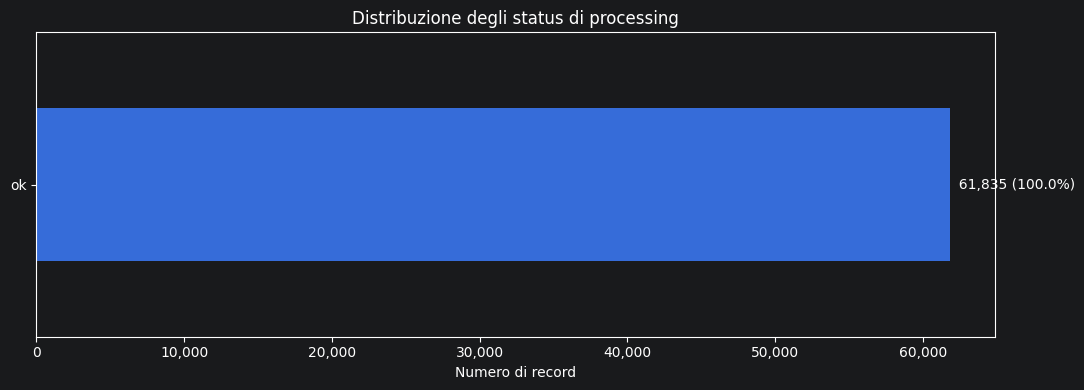

In [29]:
def add_bar_labels(ax, total: int | None = None, orientation: str = "h") -> None:
    """Aggiunge label numeriche alle barre."""
    if orientation == "h":
        for patch in ax.patches:
            width = patch.get_width()
            y = patch.get_y() + patch.get_height() / 2
            if total:
                label = f"{width:,.0f} ({width / total * 100:.1f}%)"
            else:
                label = f"{width:,.0f}"
            ax.text(width, y, "  " + label, va="center")
    else:
        for patch in ax.patches:
            height = patch.get_height()
            x = patch.get_x() + patch.get_width() / 2
            if total:
                label = f"{height:,.0f}\n{height / total * 100:.1f}%"
            else:
                label = f"{height:,.0f}"
            ax.text(x, height, label, ha="center", va="bottom")


def plot_count_distribution(
    table: pd.DataFrame,
    value_col: str,
    count_col: str,
    title: str,
    xlabel: str,
    ylabel: str = "",
    top_n: int = 25,
    save_path: Path | None = None,
) -> None:
    if table.empty:
        print(f"Nessun dato da visualizzare: {title}")
        return

    plot_df = table.head(top_n).copy()
    plot_df[value_col] = plot_df[value_col].astype(str)
    plot_df = plot_df.sort_values(count_col, ascending=True)

    ax = plot_df.plot(
        x=value_col,
        y=count_col,
        kind="barh",
        legend=False,
        figsize=(11, max(4, 0.35 * len(plot_df) + 1)),
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    add_bar_labels(ax, total=int(table[count_col].sum()), orientation="h")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

plot_count_distribution(
    status_counts,
    value_col="overall_status",
    count_col="count",
    title="Distribuzione degli status di processing",
    xlabel="Numero di record",
    save_path=FIGURES_DIR / "overall_status_distribution.png",
)

### 4.2 Controlli di qualità sul dataset finale

Qui considero come potenziali problemi: assenza del messaggio `user`, assenza delle annotazioni dentro il messaggio `user`, task o lingua mancanti.

,check,count,pct
0,missing_user_message,0,0.000000
1,missing_natural_language_text,2919,4.720627
2,missing_task_category,0,0.000000
3,missing_detected_language,0,0.000000
4,empty_code_text,19143,30.958195


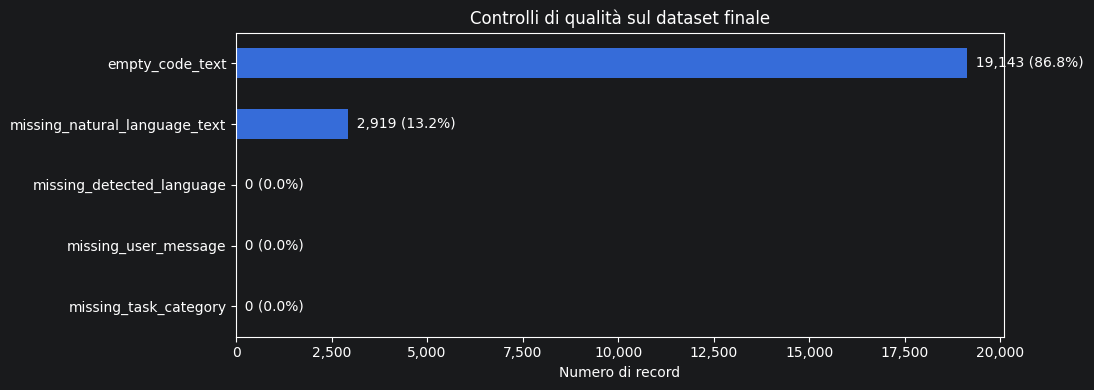

In [30]:
quality_checks = pd.DataFrame([
    {
        "check": "missing_user_message",
        "count": int((~analysis_df["has_user_message"]).sum()),
    },
    {
        "check": "missing_natural_language_text",
        "count": int((~analysis_df["has_natural_language_text"]).sum()),
    },
    {
        "check": "missing_task_category",
        "count": int(analysis_df["task_category"].isna().sum()),
    },
    {
        "check": "missing_detected_language",
        "count": int(analysis_df["detected_language"].isna().sum()),
    },
    {
        "check": "empty_code_text",
        "count": int((~analysis_df["has_code_text"]).sum()),
    },
])
quality_checks["pct"] = quality_checks["count"] / len(analysis_df) * 100
quality_checks.to_csv(TABLES_DIR / "quality_checks.csv", index=False)
display(quality_checks)

plot_count_distribution(
    quality_checks.sort_values("count", ascending=False),
    value_col="check",
    count_col="count",
    title="Controlli di qualità sul dataset finale",
    xlabel="Numero di record",
    save_path=FIGURES_DIR / "quality_checks.png",
)

## 5. Distribuzione delle lingue

Analizzo la distribuzione di `detected_language`, cioè la lingua predetta dalla classificazione LLM sulla parte naturale del prompt.

,detected_language,count,pct
0,EN,42148,68.162044
1,RU,7214,11.666532
2,FR,4652,7.523247
3,UNKNOWN,2993,4.840301
4,ZH,1408,2.277028
5,ES,583,0.942832
6,PT,529,0.855503
7,AR,500,0.808604
8,FA,316,0.511037
9,IT,281,0.454435


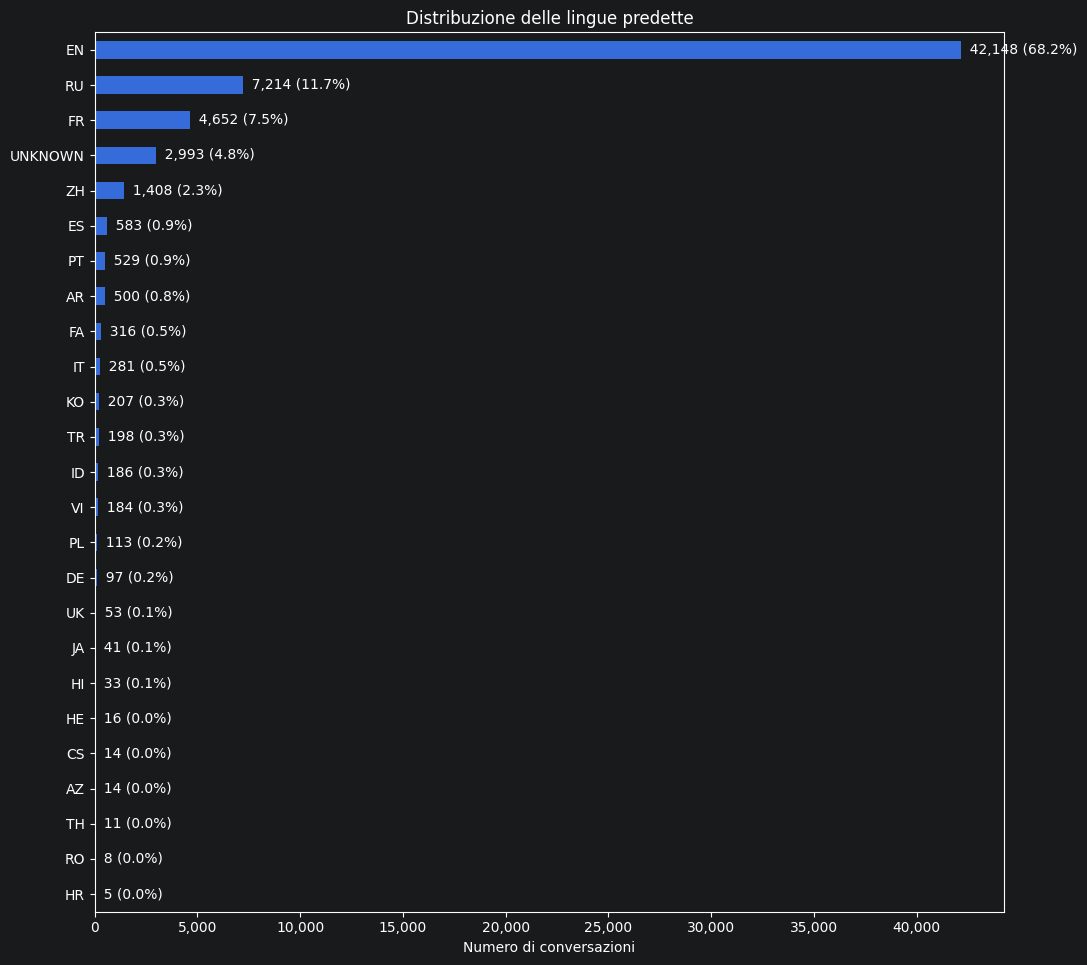

In [31]:
def value_counts_table(series: pd.Series, value_name: str) -> pd.DataFrame:
    counts = (
        series
        .fillna("MISSING")
        .astype(str)
        .value_counts(dropna=False)
        .rename_axis(value_name)
        .reset_index(name="count")
    )
    counts["pct"] = counts["count"] / counts["count"].sum() * 100
    return counts

language_distribution = value_counts_table(analysis_df["detected_language"], "detected_language")
language_distribution.to_csv(TABLES_DIR / "language_distribution.csv", index=False)

display(language_distribution.head(30))

plot_count_distribution(
    language_distribution,
    value_col="detected_language",
    count_col="count",
    title="Distribuzione delle lingue predette",
    xlabel="Numero di conversazioni",
    top_n=TOP_N,
    save_path=FIGURES_DIR / "language_distribution.png",
)

## 6. Distribuzione dei task

Analizzo la distribuzione di `task_category` sul dataset finale.

,task_category,count,pct
0,CODE_GENERATION,18478,29.882752
1,EXPLANATION,12334,19.946632
2,CODE_MODIFICATION,10091,16.319237
3,BUG_FIXING,9133,14.769952
4,AMBIGUOUS,5021,8.119997
5,OTHER,3303,5.341635
6,REFACTORING,2063,3.336298
7,DATA_QUERY,1412,2.283496


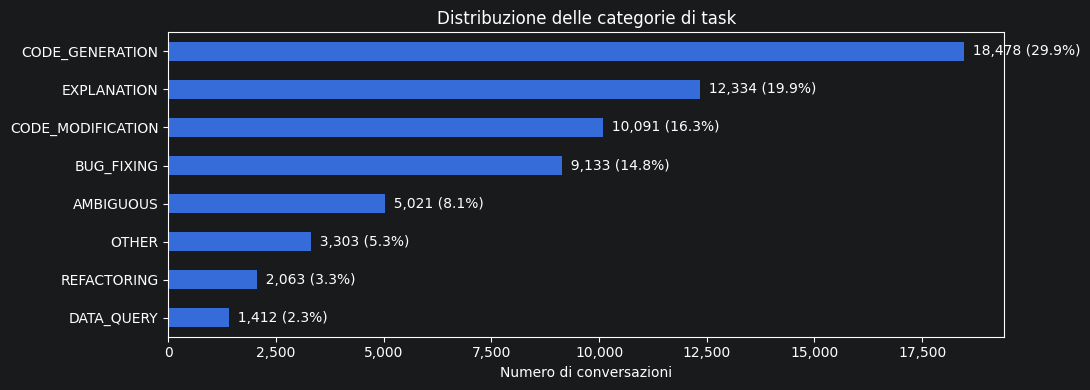

In [32]:
task_distribution = value_counts_table(analysis_df["task_category"], "task_category")
task_distribution.to_csv(TABLES_DIR / "task_distribution.csv", index=False)

display(task_distribution)

plot_count_distribution(
    task_distribution,
    value_col="task_category",
    count_col="count",
    title="Distribuzione delle categorie di task",
    xlabel="Numero di conversazioni",
    top_n=TOP_N,
    save_path=FIGURES_DIR / "task_distribution.png",
)

## 7. Distribuzione delle lingue nei task `AMBIGUOUS`

Questa analisi serve a capire se i casi ambigui sono concentrati in lingue specifiche, oppure se sono distribuiti in modo simile al dataset complessivo.

Record AMBIGUOUS: 5,021 / 61,835 (8.12%)


,detected_language,count,pct
0,UNKNOWN,2993,59.609640
1,EN,1541,30.691097
2,RU,312,6.213902
3,ZH,48,0.955985
4,ES,20,0.398327
5,FR,17,0.338578
6,IT,17,0.338578
7,AR,17,0.338578
8,FA,11,0.219080
9,PT,9,0.179247


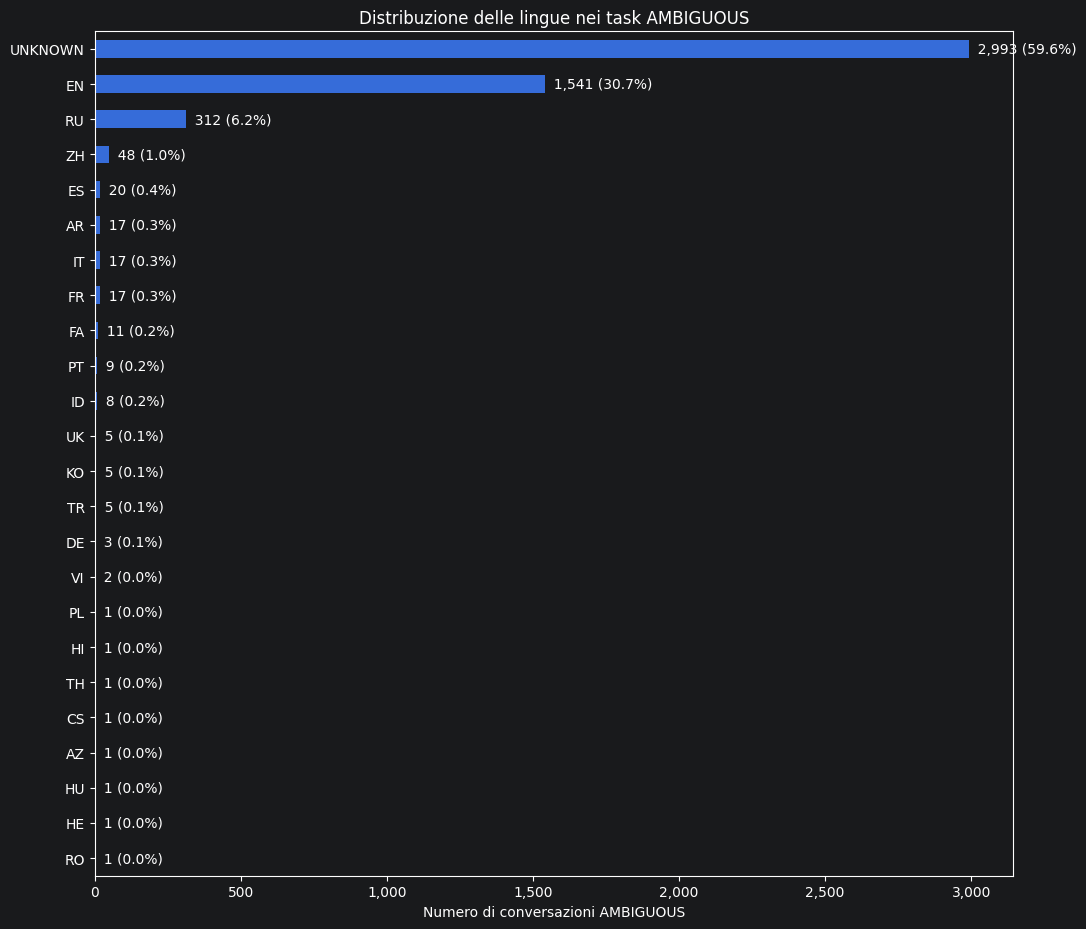

In [33]:
ambiguous_df = analysis_df.loc[analysis_df["task_category"].astype(str).eq("AMBIGUOUS")].copy()

ambiguous_count = len(ambiguous_df)
ambiguous_pct = ambiguous_count / len(analysis_df) * 100 if len(analysis_df) else 0

print(f"Record AMBIGUOUS: {ambiguous_count:,} / {len(analysis_df):,} ({ambiguous_pct:.2f}%)")

ambiguous_language_distribution = value_counts_table(
    ambiguous_df["detected_language"] if not ambiguous_df.empty else pd.Series(dtype=object),
    "detected_language",
)
ambiguous_language_distribution.to_csv(TABLES_DIR / "ambiguous_language_distribution.csv", index=False)

display(ambiguous_language_distribution.head(30))

plot_count_distribution(
    ambiguous_language_distribution,
    value_col="detected_language",
    count_col="count",
    title="Distribuzione delle lingue nei task AMBIGUOUS",
    xlabel="Numero di conversazioni AMBIGUOUS",
    top_n=TOP_N,
    save_path=FIGURES_DIR / "ambiguous_language_distribution.png",
)

### 7.1 Confronto tra distribuzione linguistica globale e AMBIGUOUS

Qui confronto, in percentuale, le lingue più frequenti nei task `AMBIGUOUS` rispetto al dataset completo.

In [34]:
if not ambiguous_language_distribution.empty:
    global_lang_pct = language_distribution.set_index("detected_language")["pct"]
    ambiguous_lang_pct = ambiguous_language_distribution.set_index("detected_language")["pct"]

    ambiguous_language_comparison = (
        pd.DataFrame({
            "global_pct": global_lang_pct,
            "ambiguous_pct": ambiguous_lang_pct,
        })
        .fillna(0)
        .assign(delta_pct=lambda df: df["ambiguous_pct"] - df["global_pct"])
        .sort_values("ambiguous_pct", ascending=False)
        .reset_index()
        .rename(columns={"index": "detected_language"})
    )

    ambiguous_language_comparison.to_csv(TABLES_DIR / "ambiguous_language_comparison.csv", index=False)
    display(ambiguous_language_comparison.head(30))
else:
    ambiguous_language_comparison = pd.DataFrame()
    print("Nessun record AMBIGUOUS disponibile per il confronto.")

,detected_language,global_pct,ambiguous_pct,delta_pct
0,UNKNOWN,4.840301,59.609640,54.769339
1,EN,68.162044,30.691097,-37.470947
2,RU,11.666532,6.213902,-5.452630
3,ZH,2.277028,0.955985,-1.321043
4,ES,0.942832,0.398327,-0.544505
5,FR,7.523247,0.338578,-7.184669
6,AR,0.808604,0.338578,-0.470026
7,IT,0.454435,0.338578,-0.115857
8,FA,0.511037,0.219080,-0.291958
9,PT,0.855503,0.179247,-0.676255


## 8. Focus sulle conversazioni in inglese

Da qui considero solo le conversazioni con `detected_language == "EN"` e analizzo la distribuzione dei task in questo sottoinsieme.

Conversazioni inglesi: 42,148 / 61,835 (68.16%)


,task_category,count,pct
0,CODE_GENERATION,14959,35.491601
1,EXPLANATION,10015,23.761507
2,CODE_MODIFICATION,6442,15.284236
3,BUG_FIXING,4454,10.567524
4,OTHER,2409,5.715574
5,AMBIGUOUS,1541,3.656164
6,DATA_QUERY,1172,2.780678
7,REFACTORING,1156,2.742716


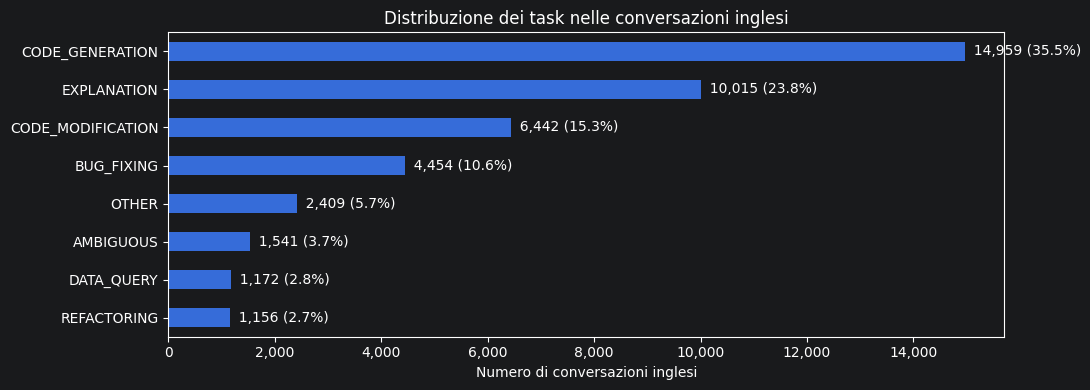

In [35]:
english_df = analysis_df.loc[analysis_df["detected_language"].astype(str).eq("EN")].copy()

english_count = len(english_df)
english_pct = english_count / len(analysis_df) * 100 if len(analysis_df) else 0

print(f"Conversazioni inglesi: {english_count:,} / {len(analysis_df):,} ({english_pct:.2f}%)")

task_distribution_en = value_counts_table(english_df["task_category"], "task_category")
task_distribution_en.to_csv(TABLES_DIR / "task_distribution_english_only.csv", index=False)

display(task_distribution_en)

plot_count_distribution(
    task_distribution_en,
    value_col="task_category",
    count_col="count",
    title="Distribuzione dei task nelle conversazioni inglesi",
    xlabel="Numero di conversazioni inglesi",
    top_n=TOP_N,
    save_path=FIGURES_DIR / "task_distribution_english_only.png",
)

### 8.1 Confronto task: dataset completo vs conversazioni inglesi

Confronto le distribuzioni percentuali dei task nel dataset completo e nel sottoinsieme inglese.

In [36]:
all_task_pct = task_distribution.set_index("task_category")["pct"]
en_task_pct = task_distribution_en.set_index("task_category")["pct"] if not task_distribution_en.empty else pd.Series(dtype=float)

task_comparison_en = (
    pd.DataFrame({
        "all_dataset_pct": all_task_pct,
        "english_only_pct": en_task_pct,
    })
    .fillna(0)
    .assign(delta_pct=lambda df: df["english_only_pct"] - df["all_dataset_pct"])
    .sort_values("english_only_pct", ascending=False)
    .reset_index()
    .rename(columns={"index": "task_category"})
)

task_comparison_en.to_csv(TABLES_DIR / "task_comparison_english_vs_all.csv", index=False)
display(task_comparison_en)

,task_category,all_dataset_pct,english_only_pct,delta_pct
0,CODE_GENERATION,29.882752,35.491601,5.608849
1,EXPLANATION,19.946632,23.761507,3.814875
2,CODE_MODIFICATION,16.319237,15.284236,-1.035000
3,BUG_FIXING,14.769952,10.567524,-4.202428
4,OTHER,5.341635,5.715574,0.373939
5,AMBIGUOUS,8.119997,3.656164,-4.463833
6,DATA_QUERY,2.283496,2.780678,0.497181
7,REFACTORING,3.336298,2.742716,-0.593582


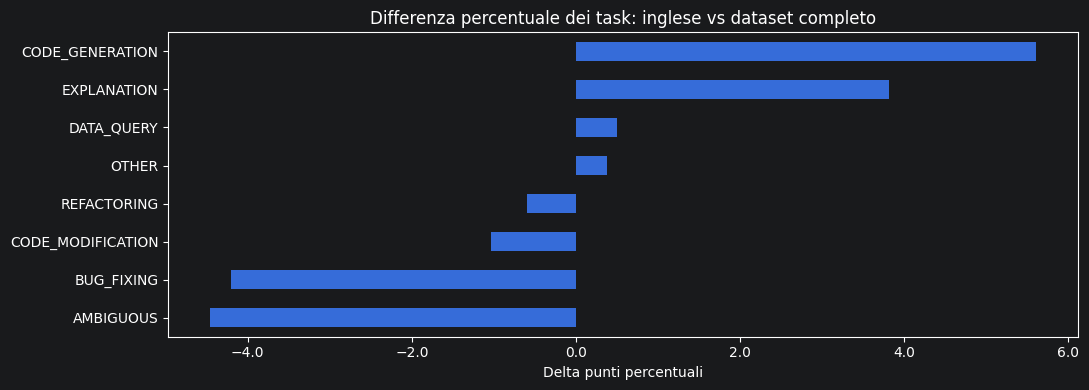

In [37]:
if not task_comparison_en.empty:
    plot_df = task_comparison_en.sort_values("delta_pct", ascending=True).copy()

    ax = plot_df.plot(
        x="task_category",
        y="delta_pct",
        kind="barh",
        legend=False,
        figsize=(11, max(4, 0.35 * len(plot_df) + 1)),
    )
    ax.set_title("Differenza percentuale dei task: inglese vs dataset completo")
    ax.set_xlabel("Delta punti percentuali")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:.1f}"))
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "task_delta_english_vs_all.png", dpi=200, bbox_inches="tight")
    plt.show()

## 9. Matrice Task × Lingua

Creo una tabella incrociata tra task e lingua. Per leggibilità mostro le lingue più frequenti, ma salvo anche la matrice completa in CSV.

In [38]:
task_language_matrix = pd.crosstab(
    analysis_df["task_category"].fillna("MISSING").astype(str),
    analysis_df["detected_language"].fillna("MISSING").astype(str),
)

task_language_matrix.to_csv(TABLES_DIR / "task_language_matrix_counts.csv")

# Versione percentuale per riga: dato un task, come si distribuiscono le lingue?
task_language_matrix_row_pct = task_language_matrix.div(task_language_matrix.sum(axis=1), axis=0) * 100
task_language_matrix_row_pct.to_csv(TABLES_DIR / "task_language_matrix_row_pct.csv")

most_frequent_languages = language_distribution["detected_language"].head(12).tolist()

display(task_language_matrix[most_frequent_languages].sort_index())

detected_language,EN,RU,FR,UNKNOWN,ZH,ES,PT,AR,FA,IT,KO,TR
task_category,,,,,,,,,,,,
AMBIGUOUS,1541,312,17,2993,48,20,9,17,11,17,5,5
BUG_FIXING,4454,1690,2007,0,289,133,125,74,68,71,33,50
CODE_GENERATION,14959,744,2108,0,169,69,52,176,32,31,16,20
CODE_MODIFICATION,6442,2194,200,0,319,141,140,114,116,56,89,74
DATA_QUERY,1172,124,22,0,46,8,4,6,2,2,1,0
EXPLANATION,10015,1153,230,0,357,66,81,82,39,56,39,28
OTHER,2409,494,57,0,110,46,29,21,39,17,15,11
REFACTORING,1156,503,11,0,70,100,89,10,9,31,9,10


## 10. Lunghezza dei prompt e quantità di codice estratto

Questa sezione non è strettamente richiesta, ma è utile come sanity check: verifica quanta parte del prompt resta come natural language e quanta viene separata come code-like artifact.

In [39]:
length_summary = analysis_df[[
    "prompt_char_len",
    "natural_language_char_len",
    "code_char_len",
]].describe(percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99]).T

length_summary.to_csv(TABLES_DIR / "length_summary.csv")
display(length_summary)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
prompt_char_len,61835.0,7228.134277,21134.298244,7.0,26.0,44.0,65.0,191.0,1427.0,5233.0,17244.8,32056.3,94322.30,784259.0
natural_language_char_len,61835.0,1140.323377,6384.415916,0.0,0.0,7.0,30.0,68.0,183.0,688.0,1986.6,3431.0,15877.42,472671.0
code_char_len,61835.0,6042.079664,18846.906402,0.0,0.0,0.0,0.0,0.0,512.0,3993.0,14951.0,28927.8,86313.86,730150.0


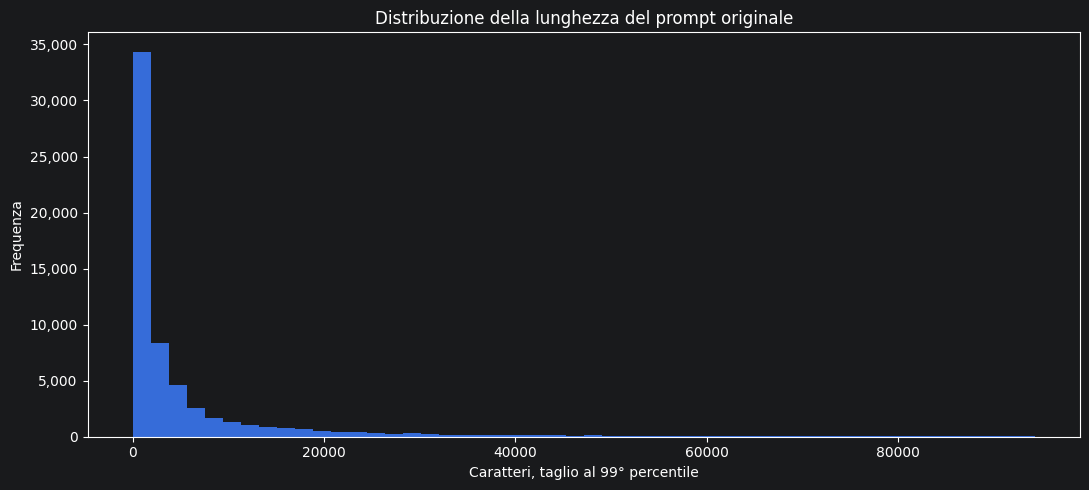

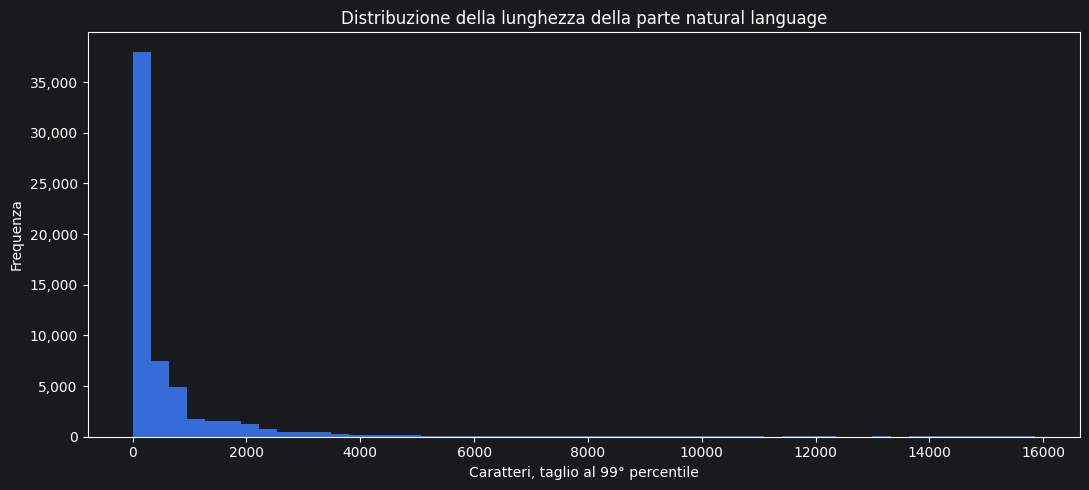

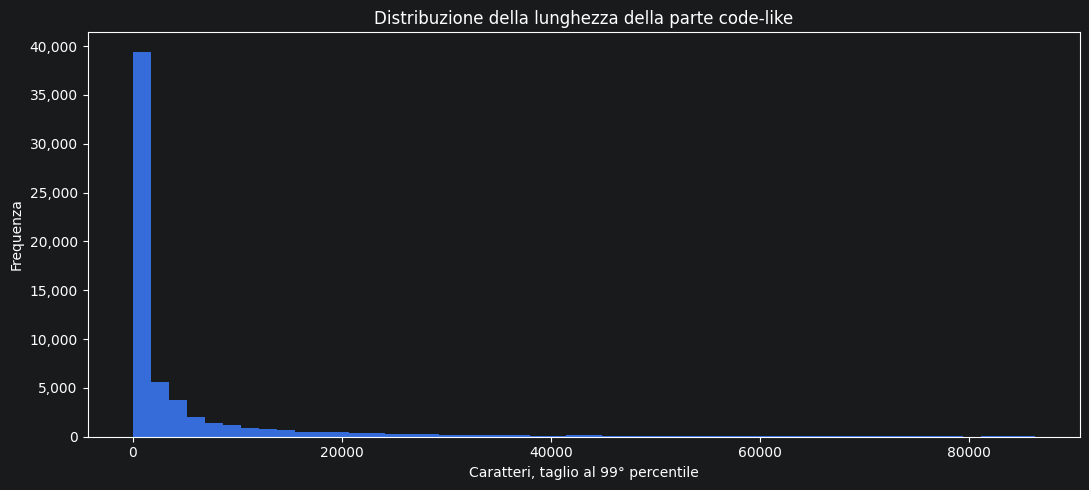

In [40]:
def plot_histogram(series: pd.Series, title: str, xlabel: str, bins: int = 50, save_path: Path | None = None) -> None:
    values = pd.to_numeric(series, errors="coerce").dropna()

    if values.empty:
        print(f"Nessun valore da visualizzare: {title}")
        return

    # Limito la coda estrema per rendere il grafico leggibile.
    upper = values.quantile(.99)
    plot_values = values.loc[values <= upper]

    ax = plot_values.plot(kind="hist", bins=bins, figsize=(11, 5))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequenza")
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

plot_histogram(
    analysis_df["prompt_char_len"],
    title="Distribuzione della lunghezza del prompt originale",
    xlabel="Caratteri, taglio al 99° percentile",
    save_path=FIGURES_DIR / "prompt_char_length_distribution.png",
)

plot_histogram(
    analysis_df["natural_language_char_len"],
    title="Distribuzione della lunghezza della parte natural language",
    xlabel="Caratteri, taglio al 99° percentile",
    save_path=FIGURES_DIR / "natural_language_char_length_distribution.png",
)

plot_histogram(
    analysis_df["code_char_len"],
    title="Distribuzione della lunghezza della parte code-like",
    xlabel="Caratteri, taglio al 99° percentile",
    save_path=FIGURES_DIR / "code_char_length_distribution.png",
)

## 11. Esempi rapidi per ispezione manuale

Estraggo alcuni esempi casuali per controllare qualitativamente la separazione `natural_language_text` / `code_text` e la classificazione task/lingua.

In [41]:
example_columns = [
    "conversation_id",
    "detected_language",
    "task_category",
    "user_content",
    "user_natural_language_text",
    "user_code_text",
]

sample_size = min(5, len(analysis_df))
examples_df = analysis_df[example_columns].sample(sample_size, random_state=RANDOM_SEED)

display(examples_df)

examples_df.to_csv(TABLES_DIR / "manual_inspection_examples.csv", index=False)

,conversation_id,detected_language,task_category,user_content,user_natural_language_text,user_code_text
12004,47977dea0c49b96d695d497ff122a44d,EN,EXPLANATION,what is enummerable and enummerator in c#? Explain in detail,what is enummerable and enummerator in c#? Explain in detail,
31407,96ee3bf29c6dd3fa6dfaff6004281c3f,EN,CODE_GENERATION,Give me code to ecommerce website,Give me code to ecommerce website,
6145,16d0721f03a61a0d7b30a16c82646efa,FR,CODE_GENERATION,"\n En tant qu'expert photographe pour des illustrations de recette de cuisine, \n écris moi un prompt qui permet de générer une image de ""suggestion de présentation""\n av...","En tant qu'expert photographe pour des illustrations de recette de cuisine, \n écris moi un prompt qui permet de générer une image de ""suggestion de présentation""\n avec mi...","Studio lighting, close-up shot with a 50mm lens at an f/2.8 aperture setting, bokeh effect, light background, food photography. --ar 32:21\n json\n {\n ""data"": <pr..."
20333,9b4244bb6a896de504f90ad59c6f8876,UK,AMBIGUOUS,"```lua\nlocal temp = {\n temperature = math.huge, opisanie = ""PIZDA GORYACHO"",\n temperature = 30, opisanie = ""teplo"",\n temperature = 20, opisanie = ""norm""\n}\n\nfor i, k i...",Че не так,"```lua\nlocal temp = {\n temperature = math.huge, opisanie = ""PIZDA GORYACHO"",\n temperature = 30, opisanie = ""teplo"",\n temperature = 20, opisanie = ""norm""\n}\nfor i, k in ..."
57707,374968708a28bc86d2c8a864ba383a47,EN,EXPLANATION,how do i make an R15 viewmodel hand in roblox studio,how do i make an R15 viewmodel hand in roblox studio,


## 12. Sintesi finale

Questa cella stampa una sintesi dei principali risultati dell'EDA.

In [42]:
summary = {
    "records": len(analysis_df),
    "source_files": int(analysis_df["_source_file"].nunique()) if "_source_file" in analysis_df.columns else None,
    "languages": int(analysis_df["detected_language"].nunique(dropna=True)),
    "task_categories": int(analysis_df["task_category"].nunique(dropna=True)),
    "english_records": int((analysis_df["detected_language"].astype(str) == "EN").sum()),
    "ambiguous_records": int((analysis_df["task_category"].astype(str) == "AMBIGUOUS").sum()),
    "records_with_code_text": int(analysis_df["has_code_text"].sum()),
    "records_without_user_message": int((~analysis_df["has_user_message"]).sum()),
}

summary_df = pd.DataFrame([summary]).T.rename(columns={0: "value"})
summary_df.to_csv(TABLES_DIR / "eda_summary.csv")
display(summary_df)

print(f"Tabelle salvate in: {TABLES_DIR}")
print(f"Figure salvate in: {FIGURES_DIR}")

,value
records,61835
source_files,7
languages,42
task_categories,8
english_records,42148
ambiguous_records,5021
records_with_code_text,42692
records_without_user_message,0


Tabelle salvate in: outputs\eda_final_v1\tables
Figure salvate in: outputs\eda_final_v1\figures
